# Model comparison

In [1]:
import os
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel
from matplotlib import pyplot as plt
import seaborn as sns
from my_fun import fig_size, add_star_between, get_experiment, filter_drug_sessions
from pathlib import Path
from glue_sessions.glue_sessions import glue_animals, glue_groups
from glmhmm import *

In [2]:
# Magics
%load_ext autoreload
%autoreload 2

In [3]:
def iqr_inliers(x):
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    return (x >= q1 - 1.5 * iqr) & (x <= q3 + 1.5 * iqr)

## 2 covariates (stim. and bias)

LL/trial: -0.83 ± 0.44 (LL/trial (bits))
LL/trial: -0.73 ± 0.41 (LL/trial (bits))
LL/trial: -0.69 ± 0.39 (LL/trial (bits))
LL/trial: -0.68 ± 0.39 (LL/trial (bits))
t = -9.351, p = 0.000
t = -8.029, p = 0.000
t = -6.814, p = 0.000


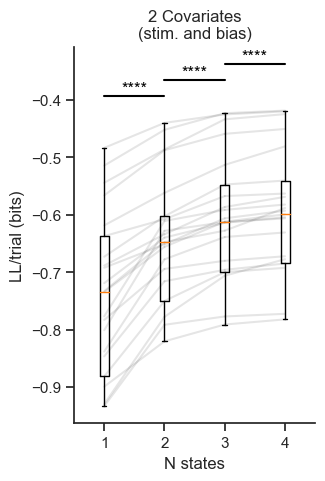

In [45]:
# df_1s_2cov = fit_all(experiments=['2AFC_2', '2AFC_3', '2AFC_4', '2AFC_6'], n_states=1, covariates=['stim_vals', 'bias'], drug=None, save=True)
# df_2s_2cov = fit_all(experiments=['2AFC_2', '2AFC_3', '2AFC_4', '2AFC_6'], n_states=2, covariates=['stim_vals', 'bias'], drug=None, save=True)
# df_3s_2cov = fit_all(experiments=['2AFC_2', '2AFC_3', '2AFC_4', '2AFC_6'], n_states=3, covariates=['stim_vals', 'bias'], drug=None, save=True)
# df_4s_2cov = fit_all(experiments=['2AFC_2', '2AFC_3', '2AFC_4', '2AFC_6'], n_states=4, covariates=['stim_vals', 'bias'], drug=None, save=True)

df_1s_2cov = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session='glmhmm/TEST/1s_2cov')
df_2s_2cov = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session='glmhmm/TEST/2s_2cov')
df_3s_2cov = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session='glmhmm/TEST/3s_2cov')
df_4s_2cov = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session='glmhmm/TEST/4s_2cov')

figsize = fig_size(n_cols=2)
figsize = (figsize[0], figsize[1]*2)
plt.figure(figsize=figsize, constrained_layout=True)

ll_1 = df_1s_2cov['LogLikelihood'].unique()
n_trials_1 = df_1s_2cov.groupby('Subject').size()
ll_2 = df_2s_2cov['LogLikelihood'].unique()
n_trials_2 = df_2s_2cov.groupby('Subject').size()
ll_3 = df_3s_2cov['LogLikelihood'].unique()
n_trials_3 = df_3s_2cov.groupby('Subject').size()
ll_4 = df_4s_2cov['LogLikelihood'].unique()
n_trials_4 = df_4s_2cov.groupby('Subject').size()

ll_1 = plot_ll(ll_1, n_trials_1, to_bits=True, positions=[0])
ll_2 = plot_ll(ll_2, n_trials_2, to_bits=True, positions=[1])
ll_3 = plot_ll(ll_3, n_trials_3, to_bits=True, positions=[2])
ll_4 = plot_ll(ll_4, n_trials_4, to_bits=True, positions=[3])

ll_1 = np.array(ll_1)
ll_2 = np.array(ll_2)
ll_3 = np.array(ll_3)
ll_4 = np.array(ll_4)

inliers_1 = iqr_inliers(ll_1)
inliers_2 = iqr_inliers(ll_2)
inliers_3 = iqr_inliers(ll_3)
inliers_4 = iqr_inliers(ll_4)

# for y0, y1 in zip(ll0, ll1):
#     plt.plot([0, 1], [y0, y1], color='k', alpha=0.1)
for y0, y1 in zip(ll_1[inliers_1 & inliers_2 & inliers_3 & inliers_4], ll_2[inliers_1 & inliers_2 & inliers_3 & inliers_4]):
    plt.plot([0, 1], [y0, y1], color='k', alpha=0.1)
for y1, y2 in zip(ll_2[inliers_1 & inliers_2 & inliers_3 & inliers_4], ll_3[inliers_1 & inliers_2 & inliers_3 & inliers_4]):
    plt.plot([1, 2], [y1, y2], color='k', alpha=0.1)
for y2, y3 in zip(ll_3[inliers_1 & inliers_2 & inliers_3 & inliers_4], ll_4[inliers_1 & inliers_2 & inliers_3 & inliers_4]):
    plt.plot([2, 3], [y2, y3], color='k', alpha=0.1)

# Paired t-test between states (not needed because sums to 1)
t_stat, p_val = ttest_rel(ll_1, ll_2)
print(f't = {t_stat:.3f}, p = {p_val:.3f}')
add_star_between(p_val, 0, 1)
t_stat, p_val = ttest_rel(ll_2, ll_3)
print(f't = {t_stat:.3f}, p = {p_val:.3f}')
add_star_between(p_val, 1, 2)
t_stat, p_val = ttest_rel(ll_3, ll_4)
print(f't = {t_stat:.3f}, p = {p_val:.3f}')
add_star_between(p_val, 2, 3)

plt.xticks([0, 1, 2, 3],['1', '2', '3', '4'])
plt.xlabel('N states')
plt.title('2 Covariates\n(stim. and bias)')
sns.despine()

ll_2_cov_means = [np.mean(ll_1), np.mean(ll_2), np.mean(ll_3), np.mean(ll_4)]

## 3 covariates  (stim., bias, and action trace)

LL/trial: -0.79 ± 0.43 (LL/trial (bits))
LL/trial: -0.72 ± 0.41 (LL/trial (bits))
LL/trial: -0.69 ± 0.39 (LL/trial (bits))
LL/trial: -0.68 ± 0.38 (LL/trial (bits))
t = -9.124, p = 0.000
t = -6.747, p = 0.000
t = -5.616, p = 0.000


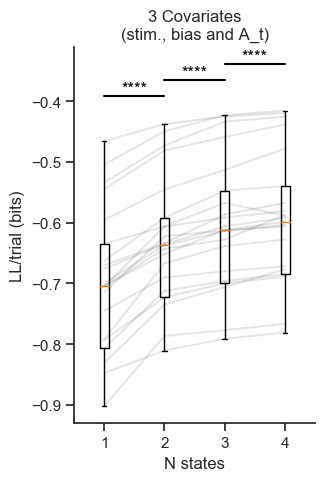

In [46]:
# df_1s_3cov = fit_all(experiments=['2AFC_2', '2AFC_3', '2AFC_4', '2AFC_6'], n_states=1, covariates=['stim_vals', 'bias', 'at_choice'], drug=None, save=True)
# df_2s_3cov = fit_all(experiments=['2AFC_2', '2AFC_3', '2AFC_4', '2AFC_6'], n_states=2, covariates=['stim_vals', 'bias', 'at_choice'], drug=None, save=True)
# df_3s_3cov = fit_all(experiments=['2AFC_2', '2AFC_3', '2AFC_4', '2AFC_6'], n_states=3, covariates=['stim_vals', 'bias', 'at_choice'], drug=None, save=True)
# df_4s_3cov = fit_all(experiments=['2AFC_2', '2AFC_3', '2AFC_4', '2AFC_6'], n_states=4, covariates=['stim_vals', 'bias', 'at_choice'], drug=None, save=True)

df_1s_3cov = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session='glmhmm/TEST/1s_3cov')
df_2s_3cov = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session='glmhmm/TEST/2s_3cov')
df_3s_3cov = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session='glmhmm/TEST/3s_3cov')
df_4s_3cov = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session='glmhmm/TEST/4s_3cov')

figsize = fig_size(n_cols=2)
figsize = (figsize[0], figsize[1]*2)
plt.figure(figsize=figsize, constrained_layout=True)

ll_1 = df_1s_3cov['LogLikelihood'].unique()
n_trials_1 = df_1s_3cov.groupby('Subject').size()
ll_2 = df_2s_3cov['LogLikelihood'].unique()
n_trials_2 = df_2s_3cov.groupby('Subject').size()
ll_3 = df_3s_2cov['LogLikelihood'].unique()
n_trials_3 = df_3s_3cov.groupby('Subject').size()
ll_4 = df_4s_3cov['LogLikelihood'].unique()
n_trials_4 = df_4s_3cov.groupby('Subject').size()

ll_1 = plot_ll(ll_1, n_trials_1, to_bits=True, positions=[0])
ll_2 = plot_ll(ll_2, n_trials_2, to_bits=True, positions=[1])
ll_3 = plot_ll(ll_3, n_trials_3, to_bits=True, positions=[2])
ll_4 = plot_ll(ll_4, n_trials_4, to_bits=True, positions=[3])

ll_1 = np.array(ll_1)
ll_2 = np.array(ll_2)
ll_3 = np.array(ll_3)
ll_4 = np.array(ll_4)

inliers_1 = iqr_inliers(ll_1)
inliers_2 = iqr_inliers(ll_2)
inliers_3 = iqr_inliers(ll_3)
inliers_4 = iqr_inliers(ll_4)

# for y0, y1 in zip(ll0, ll1):
#     plt.plot([0, 1], [y0, y1], color='k', alpha=0.1)
for y0, y1 in zip(ll_1[inliers_1 & inliers_2 & inliers_3 & inliers_4], ll_2[inliers_1 & inliers_2 & inliers_3 & inliers_4]):
    plt.plot([0, 1], [y0, y1], color='k', alpha=0.1)
for y1, y2 in zip(ll_2[inliers_1 & inliers_2 & inliers_3 & inliers_4], ll_3[inliers_1 & inliers_2 & inliers_3 & inliers_4]):
    plt.plot([1, 2], [y1, y2], color='k', alpha=0.1)
for y2, y3 in zip(ll_3[inliers_1 & inliers_2 & inliers_3 & inliers_4], ll_4[inliers_1 & inliers_2 & inliers_3 & inliers_4]):
    plt.plot([2, 3], [y2, y3], color='k', alpha=0.1)

# Paired t-test between states (not needed because sums to 1)
t_stat, p_val = ttest_rel(ll_1, ll_2)
print(f't = {t_stat:.3f}, p = {p_val:.3f}')
add_star_between(p_val, 0, 1)
t_stat, p_val = ttest_rel(ll_2, ll_3)
print(f't = {t_stat:.3f}, p = {p_val:.3f}')
add_star_between(p_val, 1, 2)
t_stat, p_val = ttest_rel(ll_3, ll_4)
print(f't = {t_stat:.3f}, p = {p_val:.3f}')
add_star_between(p_val, 2, 3)

plt.xticks([0, 1, 2, 3],['1', '2', '3', '4'])
plt.xlabel('N states')
plt.title('3 Covariates\n(stim., bias and A_t)')
sns.despine()

ll_3_cov_means = [np.mean(ll_1), np.mean(ll_2), np.mean(ll_3), np.mean(ll_4)]

# LL per state

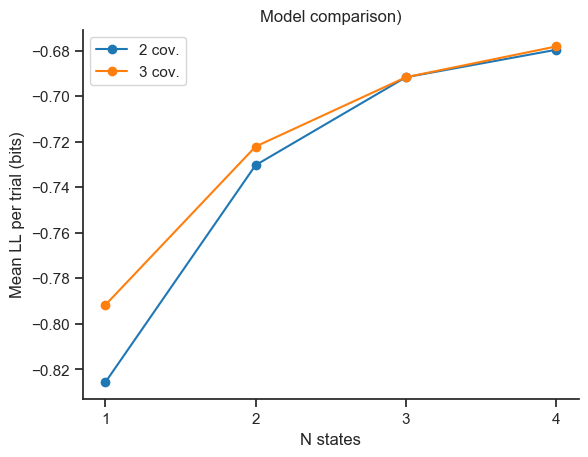

In [49]:
plt.plot(ll_2_cov_means, marker='o', label='2 cov.')
plt.plot(ll_3_cov_means, marker='o', label='3 cov.')
sns.despine()
plt.xlabel('N states')
plt.ylabel('Mean LL per trial (bits)')
plt.xticks([0, 1, 2, 3], ['1', '2', '3', '4'])
plt.title('Model comparison)')
plt.legend()

# Occupancy

In [8]:
occ_2s_2cov_saline = plot_occupancy_boxplot(df_2s_2cov[df_2s_2cov.Drug==0], figsize=figsize)
occ_2s_2cov_drug = plot_occupancy_boxplot(df_2s_2cov[df_2s_2cov.Drug==1], figsize=figsize)
occ_2s_2cov_saline['Drug'] = 0
occ_2s_2cov_drug['Drug'] = 1
occ_2s_2cov_comparison = pd.concat([occ_2s_2cov_saline, occ_2s_2cov_drug], ignore_index=True)
plt.figure(figsize=figsize, constrained_layout=True)
sns.boxplot(data=occ_2s_2cov_comparison, x='Drug', y='Engaged', palette=['tab:gray','tab:pink'], showfliers=False)
# Paired t-test between states (not needed because sums to 1)
engaged_saline = occ_2s_2cov_comparison[occ_2s_2cov_comparison['Drug'] == 0]['Engaged']
engaged_drug = occ_2s_2cov_comparison[occ_2s_2cov_comparison['Drug'] == 1]['Engaged']
t_stat, p_val = ttest_rel(engaged_saline, engaged_drug)
print(f't = {t_stat:.3f}, p = {p_val:.3f}')
add_star_between(p_val, 0, 1)
plt.xticks([0,1], ['Saline','Drug'])
plt.ylim(0, 1)
plt.xlabel('Engaged')
plt.ylabel('Occupancy')
sns.despine()
plt.title('2 states\n(2 cov.: stim., bias)')



occ_2s_3cov_saline = plot_occupancy_boxplot(df_2s_3cov[df_2s_3cov.Drug==0], figsize=figsize)
occ_2s_3cov_drug = plot_occupancy_boxplot(df_2s_3cov[df_2s_3cov.Drug==1], figsize=figsize)
occ_2s_3cov_saline['Drug'] = 0
occ_2s_3cov_drug['Drug'] = 1
occ_2s_3cov_comparison = pd.concat([occ_2s_3cov_saline, occ_2s_3cov_drug], ignore_index=True)
plt.figure(figsize=figsize, constrained_layout=True)
sns.boxplot(data=occ_2s_3cov_comparison, x='Drug', y='Engaged', palette=['tab:gray','tab:pink'], showfliers=False)
# Paired t-test between states (not needed because sums to 1)
engaged_saline = occ_2s_3cov_comparison[occ_2s_3cov_comparison['Drug'] == 0]['Engaged']
engaged_drug = occ_2s_3cov_comparison[occ_2s_3cov_comparison['Drug'] == 1]['Engaged']
t_stat, p_val = ttest_rel(engaged_saline, engaged_drug)
print(f't = {t_stat:.3f}, p = {p_val:.3f}')
add_star_between(p_val, 0, 1)
plt.xticks([0,1], ['Saline','Drug'])
plt.ylim(0, 1)
plt.xlabel('Engaged')
plt.ylabel('Occupancy')
sns.despine()
plt.title('2 states\n(3 cov.: stim., bias, At)')



occ_3s_2cov_saline = plot_occupancy_boxplot(df_3s_2cov[df_3s_2cov.Drug==0], figsize=figsize)
occ_3s_2cov_drug = plot_occupancy_boxplot(df_3s_2cov[df_3s_2cov.Drug==1], figsize=figsize)
occ_3s_2cov_saline['Drug'] = 0
occ_3s_2cov_drug['Drug'] = 1
occ_3s_2cov_comparison = pd.concat([occ_3s_2cov_saline, occ_3s_2cov_drug], ignore_index=True)
plt.figure(figsize=figsize, constrained_layout=True)
sns.boxplot(data=occ_3s_2cov_comparison, x='Drug', y='Engaged', palette=['tab:gray','tab:pink'], showfliers=False)
# Paired t-test between states (not needed because sums to 1)
engaged_saline = occ_3s_2cov_comparison[occ_3s_2cov_comparison['Drug'] == 0]['Engaged']
engaged_drug = occ_3s_2cov_comparison[occ_3s_2cov_comparison['Drug'] == 1]['Engaged']
t_stat, p_val = ttest_rel(engaged_saline, engaged_drug)
print(f't = {t_stat:.3f}, p = {p_val:.3f}')
add_star_between(p_val, 0, 1)
plt.xticks([0,1], ['Saline','Drug'])
plt.ylim(0, 1)
plt.xlabel('Engaged')
plt.ylabel('Occupancy')
sns.despine()
plt.title('3 states\n(2 cov.: stim., bias)')



occ_3s_3cov_saline = plot_occupancy_boxplot(df_3s_3cov[df_3s_3cov.Drug==0], figsize=figsize)
occ_3s_3cov_drug = plot_occupancy_boxplot(df_3s_3cov[df_3s_3cov.Drug==1], figsize=figsize)
occ_3s_3cov_saline['Drug'] = 0
occ_3s_3cov_drug['Drug'] = 1
occ_3s_3cov_comparison = pd.concat([occ_3s_3cov_saline, occ_3s_3cov_drug], ignore_index=True)
plt.figure(figsize=figsize, constrained_layout=True)
sns.boxplot(data=occ_3s_3cov_comparison, x='Drug', y='Engaged', palette=['tab:gray','tab:pink'], showfliers=False)
# Paired t-test between states (not needed because sums to 1)
engaged_saline = occ_3s_3cov_comparison[occ_3s_3cov_comparison['Drug'] == 0]['Engaged']
engaged_drug = occ_3s_3cov_comparison[occ_3s_3cov_comparison['Drug'] == 1]['Engaged']
t_stat, p_val = ttest_rel(engaged_saline, engaged_drug)
print(f't = {t_stat:.3f}, p = {p_val:.3f}')
add_star_between(p_val, 0, 1)
plt.xticks([0,1], ['Saline','Drug'])
plt.ylim(0, 1)
plt.xlabel('Engaged')
plt.ylabel('Occupancy')
sns.despine()
plt.title('3 states\n(3 cov.: stim., bias, At)')

KeyError: 'Subject'

# Playground

In [94]:
import warnings
warnings.filterwarnings('ignore')
import os
import pandas as pd
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
import seaborn as sns
import ssm
from scipy.special import expit as logistic
from matplotlib.lines import Line2D

from glmhmm import *

# Plotting style
default_figsize = np.array(plt.rcParams['figure.figsize'])
# sns.set_theme()
sns.set_style('ticks')
sns.set_context('poster')
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
%config InlineBackend.figure_format = 'retina'

# Set the parameters of the GLM-HMM
n_states = 2        # Number of discrete states (from Ashwood et al. 2020)
obs_dim = 1         # Number of observed dimensions (1 for binary choice)
n_categories = 2    # Number of categories for output (2 for binary choice)
input_dim = 2       # Input dimensions (stimulus and bias)

glmhmm = ssm.HMM(n_states, obs_dim, input_dim, observations='input_driven_obs',
                   observation_kwargs=dict(C=n_categories), transitions='standard')

# Load data from example mouse
try:
    df = pd.read_csv(r'C:\Users\Usuario\PycharmProjects\glue_sessions\2AFC_2\333.csv')  # Ephys PC
except FileNotFoundError:
    df = pd.read_csv('/home/alexis/PycharmProjects/glue_sessions/2AFC_2/333.csv')  # Cluster

# Filters for groups 1-3
df = df[df.Stage == 4].reset_index(drop=True)
df = df[df.Motor == 4].reset_index(drop=True)
# df = df[df.StimDur == 1].reset_index(drop=True)
df = df[df.P > 0].reset_index(drop=True)

# Drop misses (Choice == NaN)
df = df.dropna(subset=['Choice']).reset_index(drop=True)

covariates = ['stim_vals', 'bias']
state_label_map = {0: 'Lapse', 1: 'Engaged'}

inputs, choices = parse_glmhmm(df, covariates=covariates)

# Fitting with stop earlier if increase in LL is below tolerance specified by tolerance parameter
method = 'em'  # Expectation Maximization method
num_iters = 200 # Max number of EM iterations
tolerance = 1e-4  # Tolerance for stopping criterion
# fit_ll = glmhmm.fit(choices, inputs=inputs, method=method, num_iters=num_iters, tolerance=tolerance)

def enforce_lapse_constraint(hmm, lapse_state=1, stim_index=0):
    hmm.observations.params[lapse_state, 0, stim_index] = 0.0

N_iters = 200
lls = []

# from tqdm import trange
# pbar = trange(N_iters, desc='Fitting lapse GLM-HMM')

for _ in range(N_iters):
    ll = glmhmm.fit(
        choices,
        inputs=inputs,
        method='em',
        num_iters=1,
        initialize=(_ == 0)
    )
    print(f'EM Iteration {_+1}: Log Likelihood = {ll[-1]}')
    # ll = glmhmm.em_step(choices, inputs=inputs)  # Not implemented?
    enforce_lapse_constraint(glmhmm)
    lls.append(ll[-1])
    if _ > 1 and abs(lls[-1] - lls[-2]) < tolerance:
        break

  0%|          | 0/1 [00:00<?, ?it/s]

EM Iteration 1: Log Likelihood = -9709.38613794368


  0%|          | 0/1 [00:00<?, ?it/s]

EM Iteration 2: Log Likelihood = -9619.839457756416


  0%|          | 0/1 [00:00<?, ?it/s]

...

EM Iteration 34: Log Likelihood = -8760.729716593778


  0%|          | 0/1 [00:00<?, ?it/s]

EM Iteration 35: Log Likelihood = -8760.729838503907


  0%|          | 0/1 [00:00<?, ?it/s]

EM Iteration 36: Log Likelihood = -8760.729930665473


In [96]:
ll = glmhmm.log_likelihood(choices, inputs=inputs)
n_trials = len(df)
ll = ll / n_trials
ll = ll / np.log(2)
ll_lapse = ll
print(ll_lapse)

-0.4932399476929207


In [97]:
%%time
lls = []
for _ in range(1, 6):
    print(f'Fitting GLM-HMM with {_} states')
    n_states = _        # Number of discrete states (from Ashwood et al. 2020)
    glmhmm = ssm.HMM(n_states, obs_dim, input_dim, observations='input_driven_obs',
                       observation_kwargs=dict(C=n_categories), transitions='standard')
    glmhmm.fit(choices, inputs=inputs, method=method, num_iters=num_iters, tolerance=tolerance)
    ll = glmhmm.log_likelihood(choices, inputs=inputs)
    ll = ll / n_trials
    ll = ll / np.log(2)
    lls.append(ll)

Fitting GLM-HMM with 1 states


  0%|          | 0/200 [00:00<?, ?it/s]

Fitting GLM-HMM with 2 states


  0%|          | 0/200 [00:00<?, ?it/s]

Fitting GLM-HMM with 3 states


...

Fitting GLM-HMM with 4 states


  0%|          | 0/200 [00:00<?, ?it/s]

Fitting GLM-HMM with 5 states


  0%|          | 0/200 [00:00<?, ?it/s]

CPU times: user 28min 53s, sys: 14min 31s, total: 43min 24s
Wall time: 22min 30s


([<matplotlib.axis.XTick at 0x7f76035b0a10>,
 <a list of 5 Text xticklabel objects>)

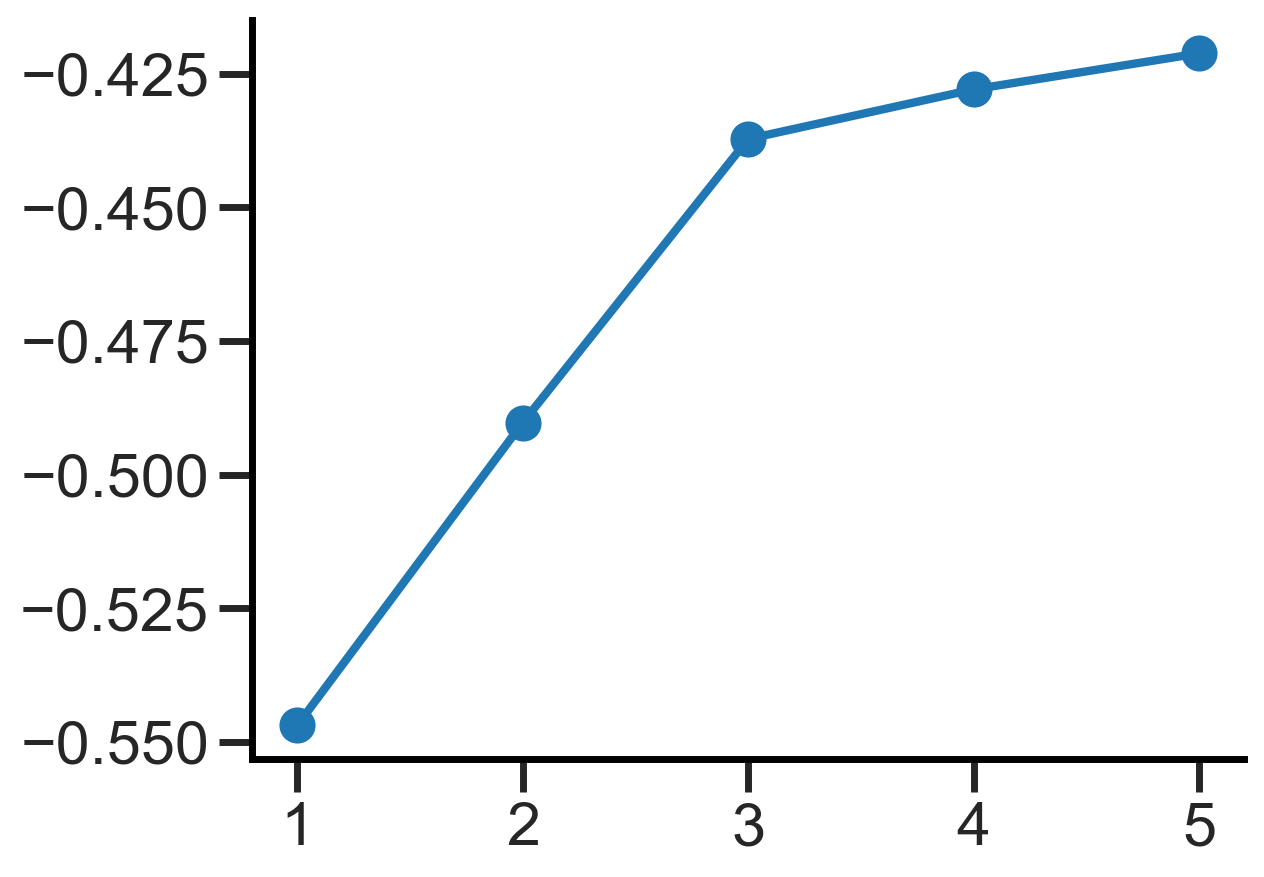

In [98]:
plt.plot(lls, marker='o')
plt.xticks(np.arange(5), ['1','2','3','4','5'])

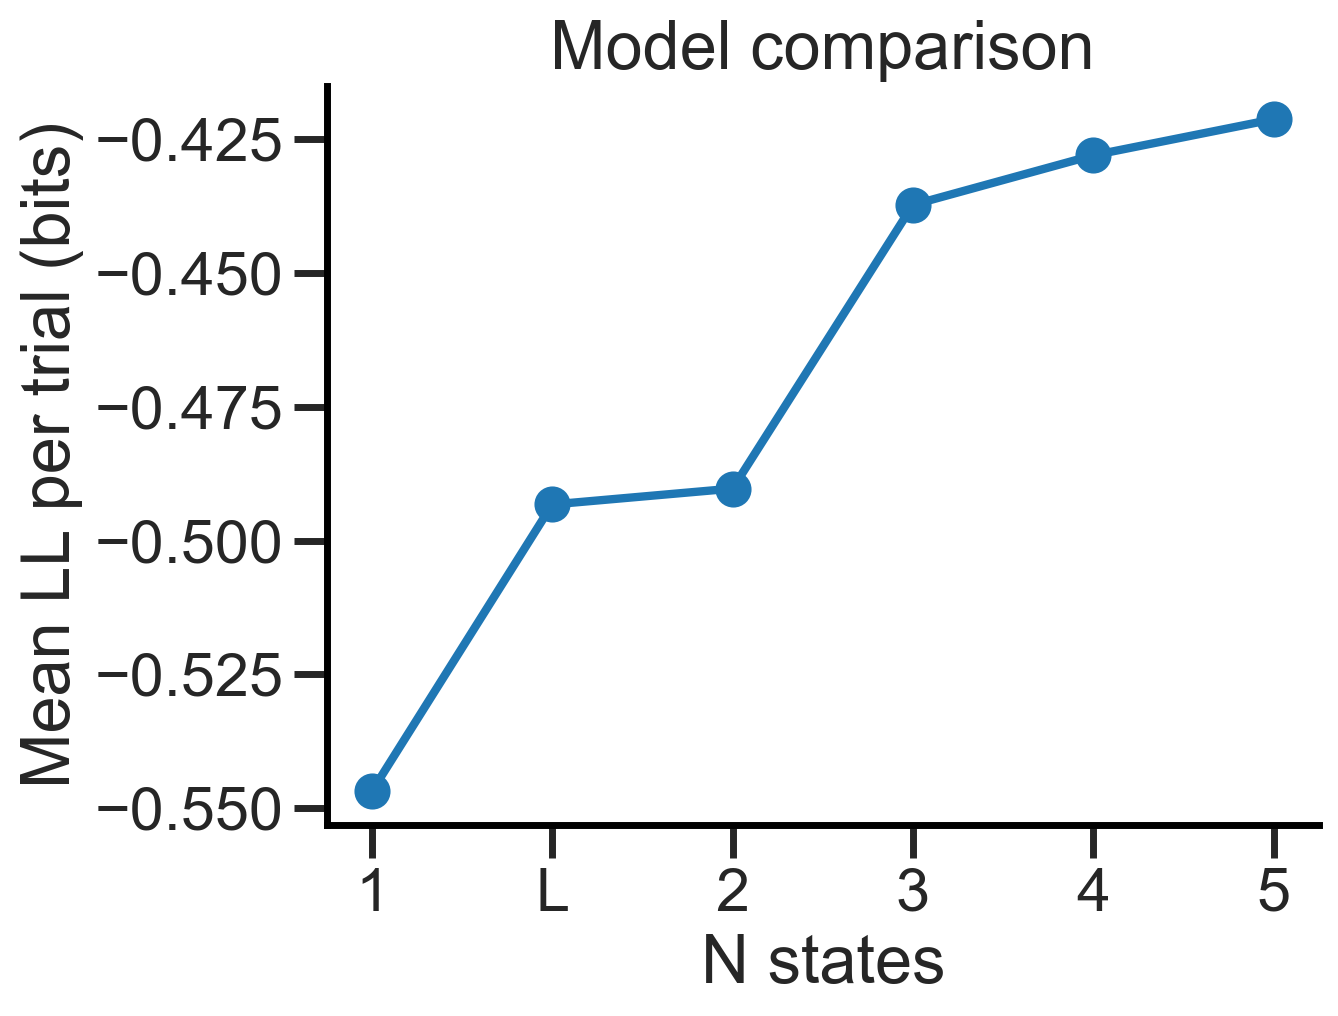

In [110]:
plt.plot(lls, marker='o')
plt.xticks(np.arange(6), ['1', 'L', '2','3','4','5'])
plt.xlabel('N states')
plt.ylabel('Mean LL per trial (bits)')
plt.title('Model comparison')
sns.despine()

# TEST